In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Loading Dataset

In [3]:
df = pd.read_csv('dataset.csv')   

print(f' Dataset loaded successfully')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

 Dataset loaded successfully
Shape: 8576 rows × 10 columns


,Country,State,Year,Region-Wise Installation Of Electricity,"Energy Value Type (Potential, Capacity, Generation)",Types Of Energy Sources,Nature Of Energy Sources,"Types Of Usage (Utility ,Captive)",Type Of Energy Sector,"Values For Renewable Electricity (UOM:MW(MegaWatt)), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SMALL HYDRO,NaN,NaN,NaN,5.25
1,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SOLAR,NaN,NaN,NaN,12.19
2,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Potential,SMALL HYDRO,RENEWABLE,NaN,NaN,7.27
3,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Potential,WIND,RENEWABLE,NaN,NaN,1277.00
4,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",NaN,Generation,BIOMASS-BAGASSE,RENEWABLE,UTILITY,UTILITY-RE,0.00


# Analyzing Data Structure

In [4]:
print('SHAPE')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')


SHAPE
Rows: 8576, Columns: 10


In [5]:
df.describe()

,"Values For Renewable Electricity (UOM:MW(MegaWatt)), Scaling Factor:1"
count,8576.00
mean,2589.54
std,8675.70
min,0.00
25%,0.00
50%,36.11
75%,1022.08
max,142560.00


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8576 entries, 0 to 8575
Data columns (total 10 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Country                                                                8576 non-null   str    
 1   State                                                                  8576 non-null   str    
 2   Year                                                                   8576 non-null   str    
 3   Region-Wise Installation Of Electricity                                1792 non-null   str    
 4   Energy Value Type (Potential, Capacity, Generation)                    8576 non-null   str    
 5   Types Of Energy Sources                                                8576 non-null   str    
 6   Nature Of Energy Sources                                               7467 non-null   str    
 7  

# Renaming Columns

In [7]:
df.columns = [
    'Country',
    'State',
    'Year',
    'Region',
    'Value_Type',       
    'Energy_Source',    
    'Nature',           
    'Usage_Type',       
    'Sector',           
    'Value_MW'          
]

print('Columns renamed:')
print(df.columns.tolist())
df.head(3)

Columns renamed:
['Country', 'State', 'Year', 'Region', 'Value_Type', 'Energy_Source', 'Nature', 'Usage_Type', 'Sector', 'Value_MW']


,Country,State,Year,Region,Value_Type,Energy_Source,Nature,Usage_Type,Sector,Value_MW
0,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SMALL HYDRO,NaN,NaN,NaN,5.25
1,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Capacity,SOLAR,NaN,NaN,NaN,12.19
2,India,Andaman And Nicobar Islands,"Financial Year (Apr - Mar), 2020",ER,Potential,SMALL HYDRO,RENEWABLE,NaN,NaN,7.27


# Drop Useless Column

In [8]:
print('Unique values in Country column:', df['Country'].unique())

df.drop(columns=['Country'], inplace=True)


Unique values in Country column: <StringArray>
['India']
Length: 1, dtype: str


# Checking Missing Values

In [9]:
df.isna().sum()

State               0
Year                0
Region           6784
Value_Type          0
Energy_Source       0
Nature           1109
Usage_Type       1792
Sector           1792
Value_MW            0
dtype: int64

In [10]:
print("Filled Missing Region Column Values with Unknown")
df['Region']=df['Region'].fillna('Unknown')

Filled Missing Region Column Values with Unknown


In [11]:
renewable_sources = df[df['Nature'] == 'RENEWABLE']['Energy_Source'].unique()
non_renewable_sources = df[df['Nature'] == 'NON-RENEWABLE']['Energy_Source'].unique()

In [12]:
renewable_sources

<StringArray>
[         'SMALL HYDRO',                 'WIND',      'BIOMASS-BAGASSE',
           'RENEWABLES',                'SOLAR',              'BIOMASS',
 'COGENERATION-BAGASSE',                'WASTE']
Length: 8, dtype: str

In [13]:
non_renewable_sources

<StringArray>
['COAL', 'DIESEL', 'HYDRO', 'NATURAL GAS', 'NUCLEAR', 'NAPHTHA', 'LIGNITE']
Length: 7, dtype: str

In [14]:
def infer_nature(row):
    if pd.notna(row['Nature']):
        return row['Nature']
    if row['Energy_Source'] in renewable_sources:
        return 'RENEWABLE'
    elif row['Energy_Source'] in non_renewable_sources:
        return 'NON-RENEWABLE'
    return 'UNKNOWN'

print('Before:', df['Nature'].isnull().sum(), 'nulls in Nature')
df['Nature'] = df.apply(infer_nature, axis=1)
print('After: ', df['Nature'].isnull().sum(), 'nulls in Nature')
print('\nNature value counts:')
print(df['Nature'].value_counts())

Before: 1109 nulls in Nature
After:  0 nulls in Nature

Nature value counts:
Nature
RENEWABLE        4768
NON-RENEWABLE    3808
Name: count, dtype: int64


In [15]:
print('Before:')
print('  Usage_Type nulls:', df['Usage_Type'].isnull().sum())
print('  Sector nulls    :', df['Sector'].isnull().sum())

df['Usage_Type'] = df['Usage_Type'].fillna('UNSPECIFIED')
df['Sector'] = df['Sector'].fillna('UNSPECIFIED')

print('\nAfter:')
print('  Usage_Type nulls:', df['Usage_Type'].isnull().sum())
print('  Sector nulls    :', df['Sector'].isnull().sum())

Before:
  Usage_Type nulls: 1792
  Sector nulls    : 1792

After:
  Usage_Type nulls: 0
  Sector nulls    : 0


In [16]:
print('=== FINAL MISSING VALUE CHECK ===')
print(df.isnull().sum())
print('\nNo missing values remaining!' if df.isnull().sum().sum() == 0 else 'Some nulls still present')

=== FINAL MISSING VALUE CHECK ===
State            0
Year             0
Region           0
Value_Type       0
Energy_Source    0
Nature           0
Usage_Type       0
Sector           0
Value_MW         0
dtype: int64

No missing values remaining!


# Extracting Numeric Part from Year Column

In [17]:
print('Before cleaning:')
print(df['Year'].unique()[:3])

df['Year'] = df['Year'].str.extract(r'(\d{4})').astype(int)

print('\nAfter cleaning:')
print(sorted(df['Year'].unique()))
print('\n Year column cleaned — now a clean integer')

Before cleaning:
<StringArray>
['Financial Year (Apr - Mar), 2020', 'Financial Year (Apr - Mar), 2019',
 'Financial Year (Apr - Mar), 2018']
Length: 3, dtype: str

After cleaning:
[np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

 Year column cleaned — now a clean integer


# Standardizing Text Columns

In [18]:
str_cols = ['State', 'Region', 'Value_Type', 'Energy_Source', 'Nature', 'Usage_Type', 'Sector']

for col in str_cols:
    df[col] = df[col].str.strip().str.upper()

print('Text columns standardized (stripped whitespace, converted to uppercase)')

df.head()

Text columns standardized (stripped whitespace, converted to uppercase)


,State,Year,Region,Value_Type,Energy_Source,Nature,Usage_Type,Sector,Value_MW
0,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,5.25
1,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SOLAR,RENEWABLE,UNSPECIFIED,UNSPECIFIED,12.19
2,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,7.27
3,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,WIND,RENEWABLE,UNSPECIFIED,UNSPECIFIED,1277.00
4,ANDAMAN AND NICOBAR ISLANDS,2020,UNKNOWN,GENERATION,BIOMASS-BAGASSE,RENEWABLE,UTILITY,UTILITY-RE,0.00


# Handling Numeric Columns

In [19]:
print('=== Value_MW Statistics ===')
print(df['Value_MW'].describe())

neg_count = (df['Value_MW'] < 0).sum()
print(f'\nNegative values: {neg_count}')


Q1 = df['Value_MW'].quantile(0.25)
Q3 = df['Value_MW'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR   

outliers = df[df['Value_MW'] > upper_fence]
print(f'\nOutliers (above {upper_fence:.2f} MW): {len(outliers)} rows')
print(outliers[['State', 'Year', 'Energy_Source', 'Value_Type', 'Value_MW']].head(10))

=== Value_MW Statistics ===
count     8576.00
mean      2589.54
std       8675.70
min          0.00
25%          0.00
50%         36.11
75%       1022.08
max     142560.00
Name: Value_MW, dtype: float64

Negative values: 0

Outliers (above 4088.33 MW): 1137 rows
                State  Year Energy_Source  Value_Type  Value_MW
20     ANDHRA PRADESH  2020          WIND    CAPACITY   4092.45
24     ANDHRA PRADESH  2020         SOLAR   POTENTIAL  38440.00
26     ANDHRA PRADESH  2020          WIND   POTENTIAL  74906.00
28     ANDHRA PRADESH  2020          COAL  GENERATION   9460.54
29     ANDHRA PRADESH  2020          COAL  GENERATION  10649.71
30     ANDHRA PRADESH  2020          COAL  GENERATION  21667.98
31     ANDHRA PRADESH  2020          COAL  GENERATION  24598.38
41     ANDHRA PRADESH  2020         SOLAR  GENERATION   5855.11
43     ANDHRA PRADESH  2020          WIND  GENERATION   7626.63
48  ARUNACHAL PRADESH  2020         SOLAR   POTENTIAL   8650.00


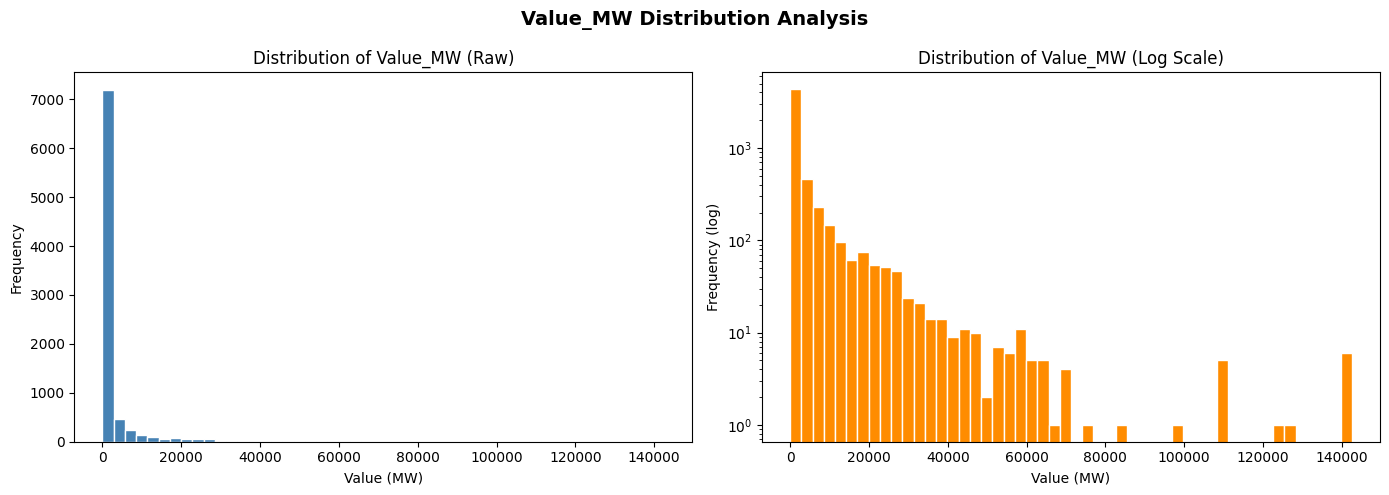

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Value_MW'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Value_MW (Raw)')
axes[0].set_xlabel('Value (MW)')
axes[0].set_ylabel('Frequency')

# Log-scale histogram (better view since data is right-skewed)
axes[1].hist(df[df['Value_MW'] > 0]['Value_MW'], bins=50,
             color='darkorange', edgecolor='white', log=True)
axes[1].set_title('Distribution of Value_MW (Log Scale)')
axes[1].set_xlabel('Value (MW)')
axes[1].set_ylabel('Frequency (log)')

plt.suptitle('Value_MW Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# NOTE: Outliers are NOT removed — large values like 142,560 MW represent
# real national-level aggregates (e.g., 'World' or country totals).
# Removing them would distort the analysis.


# Handling Duplicates

In [22]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')

if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed {dups} duplicate rows')
else:
    print('No duplicates found — dataset is clean on this front')

Duplicate rows: 0
No duplicates found — dataset is clean on this front


In [24]:
#Final Dataset
df

,State,Year,Region,Value_Type,Energy_Source,Nature,Usage_Type,Sector,Value_MW
0,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,5.25
1,ANDAMAN AND NICOBAR ISLANDS,2020,ER,CAPACITY,SOLAR,RENEWABLE,UNSPECIFIED,UNSPECIFIED,12.19
2,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,SMALL HYDRO,RENEWABLE,UNSPECIFIED,UNSPECIFIED,7.27
3,ANDAMAN AND NICOBAR ISLANDS,2020,ER,POTENTIAL,WIND,RENEWABLE,UNSPECIFIED,UNSPECIFIED,1277.00
4,ANDAMAN AND NICOBAR ISLANDS,2020,UNKNOWN,GENERATION,BIOMASS-BAGASSE,RENEWABLE,UTILITY,UTILITY-RE,0.00
...,...,...,...,...,...,...,...,...,...
8571,WEST BENGAL,2006,UNKNOWN,GENERATION,DIESEL,NON-RENEWABLE,CAPTIVE,CAPTIVE,74.36
8572,WEST BENGAL,2006,UNKNOWN,GENERATION,HYDRO,NON-RENEWABLE,CAPTIVE,CAPTIVE,0.00
8573,WEST BENGAL,2006,UNKNOWN,GENERATION,HYDRO,NON-RENEWABLE,UTILITY,STATE,468.21
8574,WEST BENGAL,2006,UNKNOWN,GENERATION,NATURAL GAS,NON-RENEWABLE,CAPTIVE,CAPTIVE,0.00
